# Лаба 233

### Необходимые импорты и доп.функции

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline # Для СВ
from scipy.optimize import curve_fit

In [9]:
def check_len(arr1, arr2):
    if len(arr1) != len(arr2):
        raise ValueError(f"Длины массивов не совпадают: {len(arr1)} != {len(arr2)}")

## Часть 1
## Распределение напряженности поля по длине волновода и для разных нагрузок

$$\boxed{КСВ(Н) =  \sqrt{\frac{A_{max}}{A_{min}}}}$$
На первой лекции была дана формула:
$$\boxed{КСВ(Н) =  \frac{1 + |r|}{1 - |r|}}$$
$$\Downarrow$$
$${|r| =  \frac{КСВ(Н) - 1}{КСВ(Н) + 1}}$$

### Необходимые функции

In [10]:
def calculate_KSVN(arr_mv: np.ndarray):
    A_max = arr_mv.max()
    A_min = arr_mv.min()
    if A_min == 0:
        return float('inf')  # КСВН = бесконечность
    return np.sqrt(A_max / A_min)

def calculate_r(KSVN):
    if KSVN == float('inf'):
        return 1
    return (KSVN - 1) / (KSVN + 1)

def find_lambda(arr_mv: np.ndarray, arr_mm: np.ndarray):
    sorted_indices = np.argsort(arr_mv)
    x1_A_min = arr_mm[sorted_indices[0]]
    x2_A_min = arr_mm[sorted_indices[1]]
    return 2 * np.abs(x1_A_min - x2_A_min)

### Данные
Измерения проводятся в пределах 1-2-ух длин волн (сантиметровые)

Волновод имеет размеры 7.2 x 3.4 мм

0. Согласованная нагрузка

In [11]:
min_SN = 196 # mv
max_SN = 201 # mv
KSVN_SN = np.sqrt(max_SN / min_SN)
r_SN = calculate_r(KSVN_SN)
print(f'Для согласованной нагрузки КСВН = {KSVN_SN:.4f}, r = {r_SN:.4f}')

Для согласованной нагрузки КСВН = 1.0127, r = 0.0063


1. Короткое замыкание

In [12]:
mv_KZ =  np.array([0.18, 168, 348, 472, 522, 480, 354, 186, 15.2, 0.21])
mm_KZ = np.array([2.7, 4, 5, 6, 7, 8, 9, 10, 11, 11.2])
check_len(mv_KZ, mm_KZ)

KSVN_KZ = calculate_KSVN(mv_KZ)
lambda_KZ = find_lambda(mv_KZ, mm_KZ)
r_KZ = calculate_r(KSVN_KZ)
print(f'Для короткого замыкания КСВН = {KSVN_KZ:.4f}, λ = {lambda_KZ:.2f} мм, r = {r_KZ:.4f}')

Для короткого замыкания КСВН = 53.8516, λ = 17.00 мм, r = 0.9635


2. Открытый конец волновода

In [13]:
mv_OK = np.array([138, 183, 174, 219, 257, 271, 251, 211, 164, 138, 138, 154])
mm_OK = np.array([5.6, 4, 7, 8, 9, 10, 11, 12, 13, 14, 14.1, 15])
check_len(mv_OK, mm_OK)

KSVN_OK = calculate_KSVN(mv_OK)
lambda_OK = find_lambda(mv_OK, mm_OK)
r_OK = calculate_r(KSVN_OK)
print(f'Для открытого конца КСВН = {KSVN_OK:.4f}, λ = {lambda_OK:.2f} мм, r = {r_OK:.4f}')

Для открытого конца КСВН = 1.4013, λ = 16.80 мм, r = 0.1671


3. Диэлектрик (сильно поглощающая диэлектрическая пластина у открытого конца)

In [14]:
mv_DLK =  np.array([101.2, 148, 131, 208, 286, 322, 318, 268, 187, 117, 166, 166])
mm_DLK = np.array([3.15, 2, 4, 5, 6, 7, 8, 9, 10, 11, 11.6, 13])
check_len(mv_DLK, mm_DLK)

KSVN_DLK = calculate_KSVN(mv_DLK)
lambda_DLK = find_lambda(mv_DLK, mm_DLK)
r_DLK = calculate_r(KSVN_DLK)
print(f'Для диэлетрика КСВН = {KSVN_DLK:.4f}, λ = {lambda_DLK:.2f} мм, r = {r_DLK:.4f}')

Для диэлетрика КСВН = 1.7838, λ = 15.70 мм, r = 0.2815


4. Рупор

In [15]:
mv_RUP =  np.array([172, 179, 174, 187, 202, 210, 208, 197, 182, 170, 168, 177])
mm_RUP = np.array([9.25, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
check_len(mv_RUP, mm_RUP)

KSVN_RUP = calculate_KSVN(mv_RUP)
lambda_RUP = find_lambda(mv_RUP, mm_RUP)
r_RUP = calculate_r(KSVN_RUP)
print(f'Для рупора КСВН = {KSVN_RUP:.4f}, λ = {lambda_RUP:.2f} мм, r = {r_RUP:.4f}')

Для рупора КСВН = 1.1180, λ = 2.00 мм, r = 0.0557


### Отрисовка графиков


In [16]:
# Код дипсика
def draw_grafics(arr_mm: np.ndarray, arr_mv: np.ndarray, title: str):
    plt.figure(figsize=(9, 6))

    # Сортируем данные по arr_mm для правильной работы сплайна
    sorted_indices = np.argsort(arr_mm)
    arr_mm_sorted = arr_mm[sorted_indices]
    arr_mv_sorted = arr_mv[sorted_indices]

    # Исходные точки
    plt.scatter(arr_mm, arr_mv, color='b', label='Эксп', marker='o')

    # 1. Синусоидальная аппроксимация
    def sin_func(x, A, B, C, D):
        """ A * sin(B*x + C) + D """
        return A * np.sin(B * x + C) + D
    
    # Подбираем параметры
    p0 = [np.ptp(arr_mv)/2, 2*np.pi/(arr_mm.max()-arr_mm.min()), 0, np.mean(arr_mv)]  # начальные приближения
    params, _ = curve_fit(sin_func, arr_mm_sorted, arr_mv_sorted, p0=p0)
    A, B, C, D = params
    
    # Сглаженная кривая (сплайн)
    d_smooth = np.linspace(arr_mm.min(), arr_mm.max(), 300)
    spline = make_interp_spline(arr_mm_sorted, arr_mv_sorted, k=3)
    U_smooth = spline(d_smooth)
    plt.plot(d_smooth, U_smooth, '-', linewidth=2, label='Сглаженная кривая', color='blue')
    
    # Синусоидальная аппроксимация
    sin_fit = sin_func(d_smooth, A, B, C, D)
    plt.plot(d_smooth, sin_fit, '--', linewidth=2, label=f'Синус: {A:.2f}·sin({B:.3f}x + {C:.2f}) + {D:.2f}', color='red')
    
    plt.title(f'График распределения напряженности поля вдоль волновода {title}')
    plt.xlabel('мм')
    plt.ylabel('мВ')
    plt.grid(True)
    ax = plt.gca()
    ax.locator_params(axis='x', nbins=25)
    ax.locator_params(axis='y', nbins=25)
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()
    
    print(f"Параметры синусоиды:")
    print(f"  A (амплитуда) = {A:.4f}")
    print(f"  B (частота) = {B:.4f}")
    print(f"  C (фаза) = {C:.4f}")
    print(f"  D (смещение) = {D:.4f}")

1. Короткое замыкание

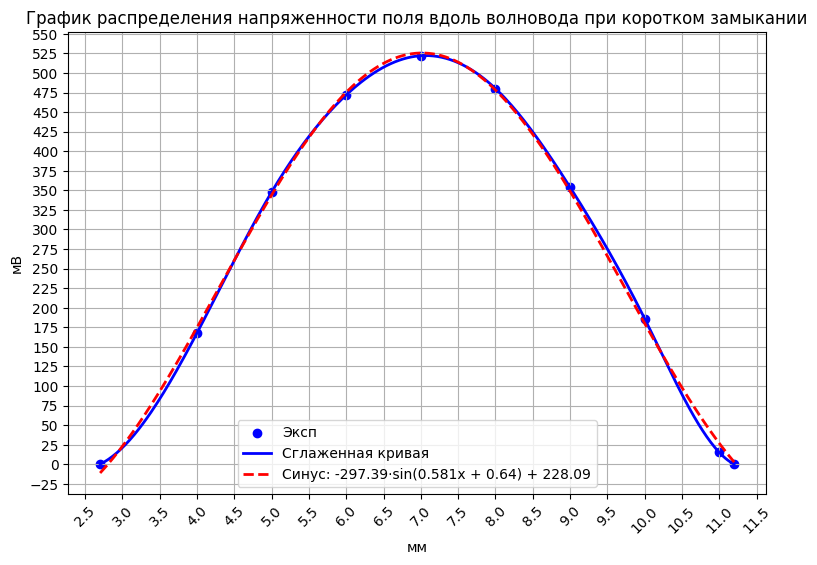

Параметры синусоиды:
  A (амплитуда) = -297.3949
  B (частота) = 0.5806
  C (фаза) = 0.6396
  D (смещение) = 228.0931
λ = 17.00 мм 


In [17]:
draw_grafics(mm_KZ, mv_KZ, 'при коротком замыкании')
print(f'λ = {lambda_KZ:.2f} мм ')

2. Открытый конец волновода

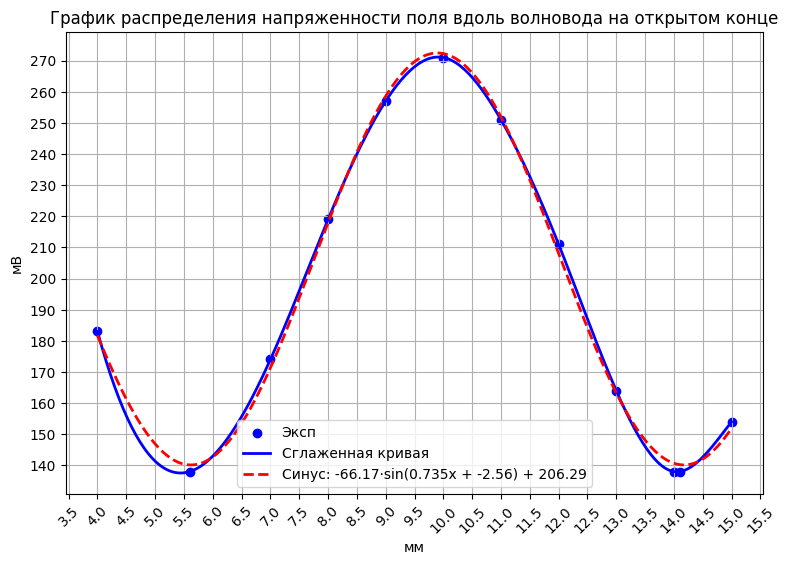

Параметры синусоиды:
  A (амплитуда) = -66.1661
  B (частота) = 0.7345
  C (фаза) = -2.5571
  D (смещение) = 206.2940
λ = 16.80 мм 


In [18]:
draw_grafics(mm_OK, mv_OK, 'на открытом конце')
print(f'λ = {lambda_OK:.2f} мм ')

3. Диэлектрик (сильно поглощающая диэлектрическая пластина у открытого конца)

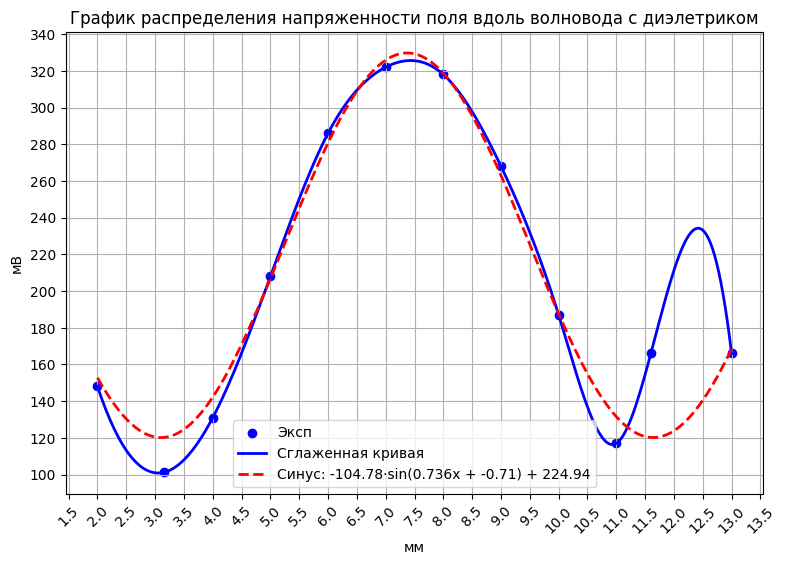

Параметры синусоиды:
  A (амплитуда) = -104.7760
  B (частота) = 0.7359
  C (фаза) = -0.7121
  D (смещение) = 224.9439
λ = 15.70 мм 


In [19]:
draw_grafics(mm_DLK, mv_DLK, 'с диэлетриком')
print(f'λ = {lambda_DLK:.2f} мм ')

4. Рупор

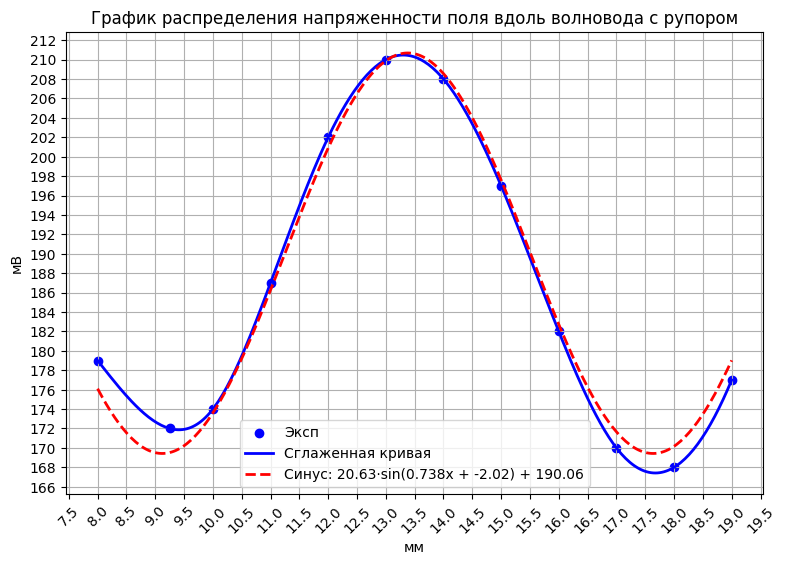

Параметры синусоиды:
  A (амплитуда) = 20.6292
  B (частота) = 0.7380
  C (фаза) = -2.0192
  D (смещение) = 190.0558
λ = 2.00 мм 


In [20]:
draw_grafics(mm_RUP, mv_RUP, 'с рупором')
print(f'λ = {lambda_RUP:.2f} мм ')

### Определение диэлектрической проницаемости
$$ r = \frac{n_1 - n_2}{n_1 + n_2}$$
$$n_1 = 1 $$ $$ n_2 \approx \sqrt{\varepsilon}$$
$$\Downarrow$$
$$ r = \frac{1 - \sqrt{\varepsilon}}{1 + \sqrt{\varepsilon}}$$
$$\Downarrow$$
$$\boxed{\varepsilon = \left( \frac{1 - r}{1 + r} \right)^2}$$

Также помним:
$$|r| = \frac{КСВ(Н) - 1}{КСВ(Н) + 1}$$

Так как пластина находится в конце волновода (отражение от диэлектрика): $r = -|r|$

$$r = -\frac{КСВ(Н) - 1}{КСВ(Н) + 1}$$
$$\Downarrow$$
$$\varepsilon = \left( \frac{1 - r}{1 + r} \right)^2 = КСВ(Н)^2$$

Таким образом:

$$\boxed{\varepsilon = \text{КСВ(Н)}^2}$$

In [21]:
eps = KSVN_DLK**2
print(f'Диэлетрическая проницаемость ε = {eps:.4f}')

Диэлетрическая проницаемость ε = 3.1818


## Часть 4
## Полное внутреннее отражение на диэлектрической призме

### Теоретические формулы для нарушенного ПВО (дипсик)

**Условие полного внутреннего отражения:**

$$\theta_i > \theta_{кр} = \arcsin\left(\frac{n_2}{n_1}\right)$$

**Коэффициент затухания эванесцентной волны:**

$$\kappa = \frac{2\pi}{\lambda} \sqrt{n_1^2 \sin^2\theta_i - n_2^2}$$

**Интенсивность прошедшего сигнала:**

$$I(d) = I_0 \cdot e^{-2\kappa d}$$

**Глубина проникновения (расстояние, на котором поле убывает в $e$ раз):**

$$\delta = \frac{1}{\kappa} = \frac{\lambda}{2\pi \sqrt{n_1^2 \sin^2\theta_i - n_2^2}}$$

**В полулогарифмических координатах:**

$$\ln\left(\frac{I(d)}{I_0}\right) = -2\kappa \cdot d$$

### Данные

In [22]:
mv_PRZM =  np.array([324, 304, 252, 218, 179, 138, 84.4, 44.2, 26.4, 21.4, 19.2, 14.4, 7.7, 2.44])
mm_PRZM = np.array([3.9, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17])
check_len(mv_PRZM, mm_PRZM)


### Отрисовка графиков

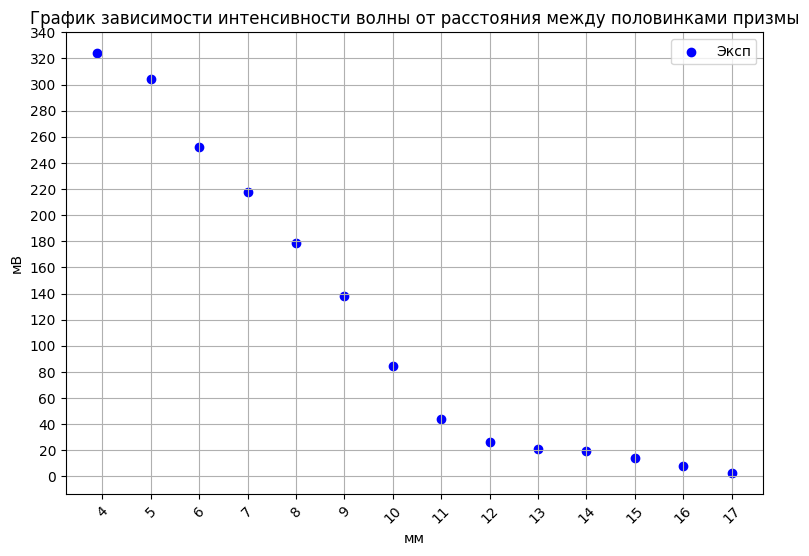

In [23]:
plt.figure(figsize=(9, 6))

plt.scatter(mm_PRZM, mv_PRZM,  color='b', label='Эксп', marker='o')

plt.title(f'График зависимости интенсивности волны от расстояния между половинками призмы')
plt.xlabel('мм')
plt.ylabel('мВ')
plt.grid(True)
ax = plt.gca()
ax.locator_params(axis='x', nbins=25)
ax.locator_params(axis='y', nbins=25)
plt.xticks(rotation=45)  # поворот на 45 градусов
plt.legend()

plt.show()

/tmp/ipykernel_86616/519892146.py:4: RuntimeWarning: overflow encountered in exp
  return I0 * np.exp(-2 * kappa * d)


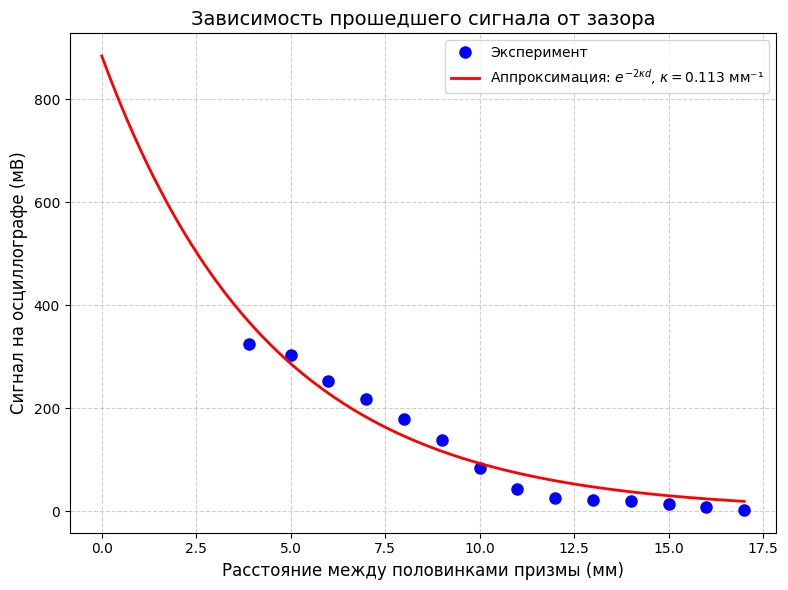

In [24]:
# Код дипсика
# Теоретическая функция: экспоненциальное затухание
def exp_decay(d, I0, kappa):
    return I0 * np.exp(-2 * kappa * d)

# Аппроксимация экспериментальных данных
popt, pcov = curve_fit(exp_decay, mm_PRZM, mv_PRZM, p0=[100, 0.5])
I0_fit, kappa_fit = popt

# Создаём ПЛАВНУЮ кривую (много точек для гладкости)
d_smooth = np.linspace(0, max(mm_PRZM), 200)
U_smooth = exp_decay(d_smooth, I0_fit, kappa_fit)

# Строим график
plt.figure(figsize=(8, 6))

# Экспериментальные точки (только точки, без линий!)
plt.plot(mm_PRZM, mv_PRZM, 'o', markersize=8, label='Эксперимент', color='blue')

# Теоретическая плавная кривая
plt.plot(d_smooth, U_smooth, '-', linewidth=2, label=f'Аппроксимация: $e^{{-2\\kappa d}}$, $\\kappa = {kappa_fit:.3f}$ мм⁻¹', color='red')

plt.xlabel('Расстояние между половинками призмы (мм)', fontsize=12)
plt.ylabel('Сигнал на осциллографе (мВ)', fontsize=12)
plt.title('Зависимость прошедшего сигнала от зазора', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()